In [1]:
# RNN 모델
# RNN 실습
# - 과거의 sin 값들을 입력받아 다음 시점의 값을 예측

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [3]:
# 1. 시계열 데이터 생성

# 0~100 까지 총 1000개의 숫자를 일정한 간격으로 생성
time = np.linspace(0, 100, 1000)

# sin 함수를 사용하여 시계열 데이터 생성
data = np.sin(time)
data

array([ 0.00000000e+00,  9.99330162e-02,  1.98865536e-01,  2.95807081e-01,
        3.89787104e-01,  4.79864709e-01,  5.65138069e-01,  6.44753455e-01,
        7.17913784e-01,  7.83886601e-01,  8.42011406e-01,  8.91706275e-01,
        9.32473678e-01,  9.63905466e-01,  9.85686954e-01,  9.97600074e-01,
        9.99525555e-01,  9.91444120e-01,  9.73436677e-01,  9.45683512e-01,
        9.08462478e-01,  8.62146222e-01,  8.07198446e-01,  7.44169268e-01,
        6.73689717e-01,  5.96465408e-01,  5.13269488e-01,  4.24934884e-01,
        3.32345974e-01,  2.36429728e-01,  1.38146426e-01,  3.84800478e-02,
       -6.15715795e-02, -1.61006773e-01, -2.58830020e-01, -3.54061947e-01,
       -4.45749125e-01, -5.32973611e-01, -6.14862143e-01, -6.90594881e-01,
       -7.59413613e-01, -8.20629350e-01, -8.73629220e-01, -9.17882606e-01,
       -9.52946458e-01, -9.78469728e-01, -9.94196886e-01, -9.99970476e-01,
       -9.95732696e-01, -9.81525973e-01, -9.57492539e-01, -9.23873010e-01,
       -8.81003973e-01, -

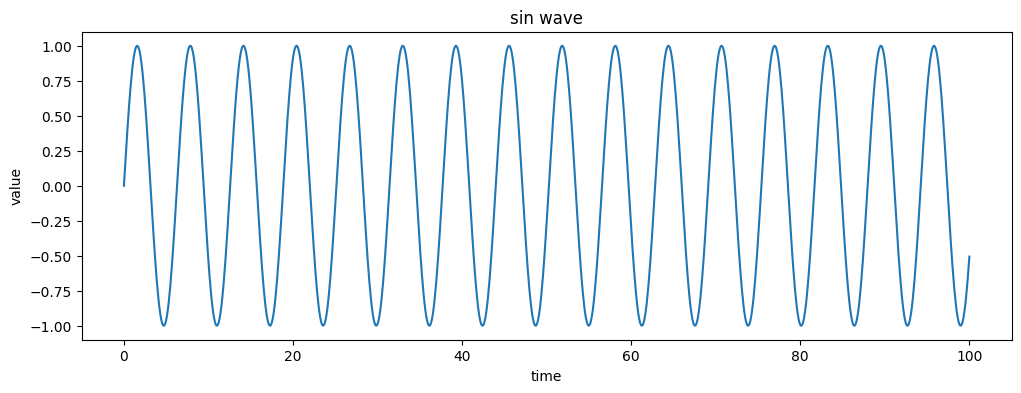

In [4]:
# 2. 데이터 확인
plt.figure(figsize=(12,4))
plt.plot(time, data)
plt.title('sin wave')
plt.xlabel('time')
plt.ylabel('value')
plt.show()

In [5]:
# 3. 학습 데이터 설정
# 최근 20개 데이터를 보고 다음 값을 예측
sequence_length = 20

X = []
y = []

for i in range(len(data) - sequence_length):
  X.append(data[i:i + sequence_length])           # i번째부터 20개 데이터를 입력값으로 사용
  y.append(data[i + sequence_length])             # 입력데이터 바로 다음값을 정답으로 사용

# 리스트를 numpy 배열로 변환
X = np.array(X)
y = np.array(y)

In [8]:
# 4. RNN 입력 형태로 데이터 변환
# RNN 입력데이터(3차원 데이터) 아래와 같이
# - samples : 전체 학습 데이터 개수
# - timesteps : 한번에 보는 시간 구간
# - features : 각 시점에서 사용하는 특성 개수     <-- 각 시간마다 sin값 하나만 사용되기 때문에 features = 1 이됨
print('변환전 X shape : ', X.shape)

X = X.reshape(
  X.shape[0],         # 전체 데이터 개수
  X.shape[1],         # SEQUENCE 개수 = 20
  1                   # feature 개수 = 1
)

print('변환후 X shape : ', X.shape)
print('변환전 y shape : ', y.shape)

변환전 X shape :  (980, 20, 1)
변환후 X shape :  (980, 20, 1)
변환전 y shape :  (980,)


In [9]:
# 5. 학습데이터 분할
split = int(len(X) * 0.8)   # 학습데이터 80%
X_train = X[:split]         # 앞에서 80% 슬라이스 학습데이터로 사용
X_test = X[split:]          # 뒤에서 20% 슬라이스 테스트데이터로 사용

# 정답 데이터도 동일하게
y_train = y[:split]
y_test = y[split:]

In [12]:
# 6. RNN 모델 정의
model = Sequential()    # 순차형 신경망 생성

# RNN 레이어 추가
model.add(
  SimpleRNN(
    units=32,                               # rnn 내부의 hidden state 크기를 32로 설정
    input_shape=(sequence_length, 1)        # 각 시간마다 20개의 시간 데이터 들어오고, 시간마다 1개의 feature를 사용
  )
)

# 출력층
model.add(Dense(1))

# 모델 구조 확인
model.summary()

/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 7. 모델 컴파일 설정
model.compile(
  optimizer='adam',
  loss='mse'            # 실제 값과 예측값의 제곱한 값(평가)
)

In [ ]:
# 8. 모델 학습
history = model.fit(
  X_train,
  y_train,
  epochs=30,
  batch_size=32,
  validation_split=0.2,
  verbose=1               # 학습 진행 상황 출력 옵션
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0393 - val_loss: 0.0060
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055 - val_loss: 0.0034
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 6.3616e-04
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0880e-04 - val_loss: 1.2046e-04
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0709e-05 - val_loss: 7.4245e-05
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0926e-05 - val_loss: 5.0548e-05
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4527e-05 - val_loss: 3.9838e-05
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5857e-05 - val_loss: 3.2213e-05
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9792e-05 - val_loss: 3.3967e-05
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7294e-05 - val_loss: 2.1604e-05
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3291e-05 - val_loss: 2.1121e-05
Epoch

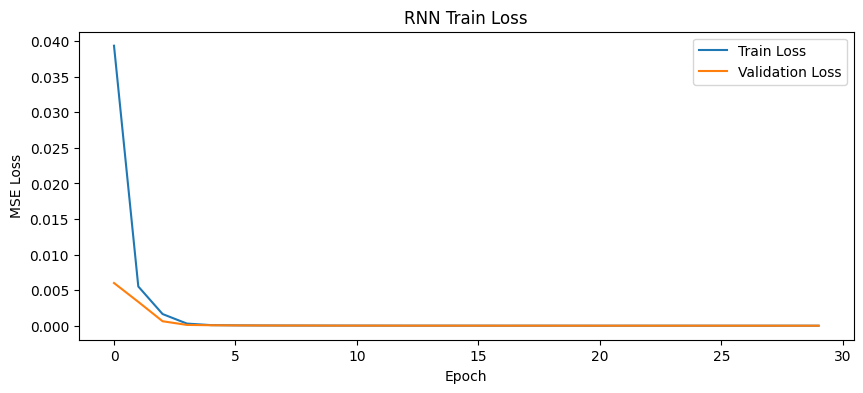

In [15]:
# 9. 학습 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('RNN Train Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()    # 범례 표시
plt.show()

In [16]:
# 10. 테스트 데이터 예측
y_pred = model.predict(X_test)

y_prod = y_pred.flatten()       # (데이터개수, 1)  --> 1차원 배열로 변환

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


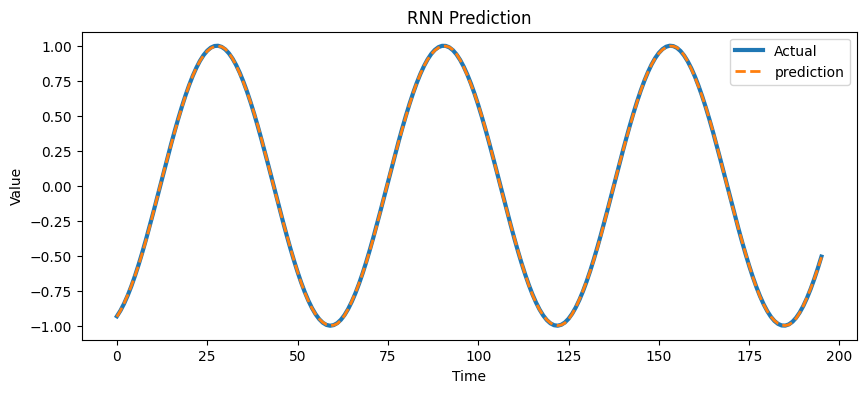

In [17]:
# 11. 실제값과 예측값 비교
plt.figure(figsize=(10,4))
plt.plot(y_test, label='Actual', linewidth=3)
plt.plot(y_pred, label='prediction', linestyle='--', linewidth=2)

plt.title('RNN Prediction')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()    # 범례 표시
plt.show()

In [18]:
# 12. 미래값 예측
# 앞으로 몇 개의 시점을 예측 할것인지 시점 구간 정의
feature_steps = 100

# 미래 예측 결과를 저장할 리스트
future_predictions = []

# sequence length = 20 을 가져와서 첫번째 미래 값 예측
current_sequence = data[-sequence_length:].copy()

# 지정한 미래 시점만큼 반복
for i in range(feature_steps):
  input_sequence = current_sequence.reshape(                # 새로운 입력데이터를 3차원으로 변환 (예측할 데이터, 과거 20개 시점, feature 1개)
    1, sequence_length, 1
  )

  # 현재 20개의 값을 이용해서 다음 시점을 예측
  next_value  = model.predict(
    input_sequence,
    verbose = 0
  )[0][0]

  # 에측된 값을 미레 예측 리스트에 저장
  future_predictions.append(next_value)

  # 100개의  시점 예측을 위 방식으로 반복하며 하나씩 미래값 예측
  current_sequence = np.append(current_sequence[1:], next_value)

# 리스트를 numpy 배열로 변환
future_predictions = np.array(future_predictions)

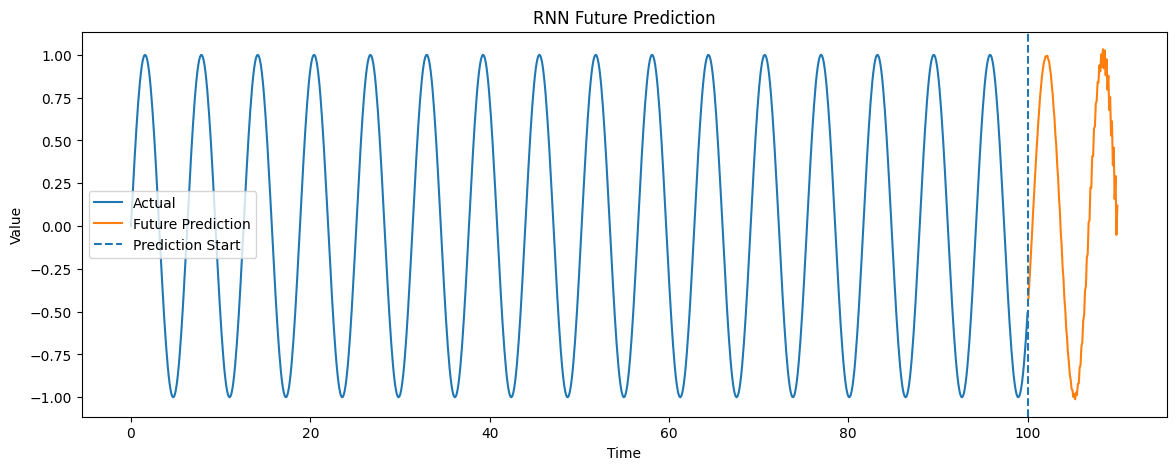

In [19]:
# 13. 미래값 결과 시각화
time_step = time[1] - time[0]         # 0.1 간격 설정

# 마지막 시간 이후부터 미래 시간축 생성
future_time=(
  time[-1] + time_step * np.arange(1, feature_steps + 1)
)

plt.figure(figsize=(14,5))
plt.plot(time, data, label='Actual')                                    # 기존 실제 sin 데이터 그리기
plt.plot(future_time, future_predictions, label='Future Prediction')    # rnn이 예측한 미래 데이터 출력

plt.axvline(x=time[-1], linestyle='--', label='Prediction Start')       # 현재 시점과 미래가 나누어지는 지점 표시

plt.title('RNN Future Prediction')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()